In [7]:
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'DeJavu Sans'
plt.rcParams['font.sans-serif'] = ['Helvetica', 'Arial', 'Open Sans']
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12


## Notebook to run the figures in the Supporting Information for the paper

SIFig 1: Changes to the stiffness of the cell wall (Youngs modulus) do not qualitatively impact the results. Introducing radial stiffening (anisotropy – red circles) increases the resulting pore area.



17


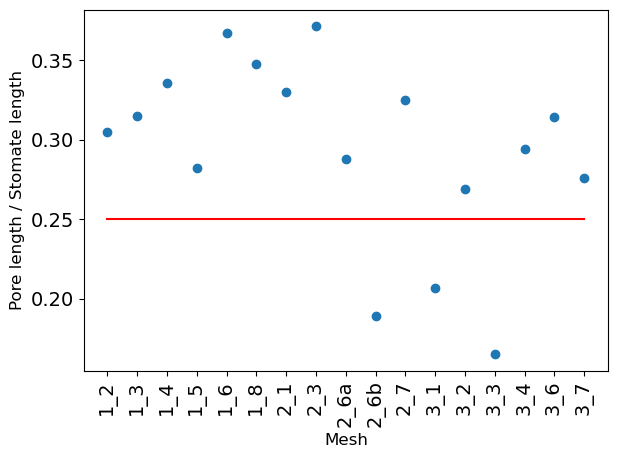

Selected meshes: ['1_2', '1_3', '1_4', '1_5', '1_6', '1_8', '2_1', '2_3', '2_6a', '2_7', '3_2', '3_4', '3_6', '3_7']


In [9]:
import sys
from pathlib import Path

src_path = str(Path.cwd().parent / "src")
if src_path not in sys.path:
    sys.path.insert(0, src_path)

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

## Results dataframes
confocal_df = pd.read_csv("../output/confocal_results_df_batch.csv")
idealised_df = pd.read_csv("../output/idealised_chosen_results.csv")

## Set the colours for the three mesh types
colours = {
    'empirical': 'magenta',
    'anisotropic': "#8A0CA1",
    'idealised_circular': 'orange',
    'idealised_oval': 'green',
    'midsection' : 'black',
    'tip' : "#CC79A7"
}

# Set the default font size for all plots
plt.rcParams.update({'font.size': 14})

## Set the name for each mesh
mesh_dcr = "Sample"

## Choose meshes to include based on their pore length : length
stomata_length = [43, 40,40.5, 48.2, 45.2, 40.3, 37, 39.6, 37.5, 36, 40, 42.1, 41.6, 40.6, 40.5, 45.5, 41]
pore_length = [13.1, 12.6, 13.6, 13.6, 16.6, 14.0, 12.2, 14.7, 10.8, 6.8, 13.0, 8.7, 11.2, 6.7, 11.9, 14.3, 11.3]
mesh_ids =["1_2","1_3","1_4","1_5","1_6","1_8","2_1", "2_3", "2_6a", "2_6b", "2_7","3_1","3_2", "3_3", "3_4","3_6", "3_7"]
print(len(mesh_ids))

pore_proportion = [p / s for p, s in zip(pore_length, stomata_length)]

plt.plot(mesh_ids, pore_proportion, 'o')
xs = np.arange(0,len(stomata_length))
ys = np.ones(len(xs)) * 0.25
plt.plot(xs,ys,'r-')

plt.xlabel('Mesh')
plt.ylabel('Pore length / Stomate length')
plt.xticks(rotation=90)
plt.tight_layout() 
plt.savefig("../Figures/SI/mesh_selection.png")
plt.show()

## Based on this plot, let's take a threshold of 0.25

threshold = 0.25
prop_mask = [p > threshold for p in pore_proportion]
selected_meshes = [m for m, keep in zip(mesh_ids, prop_mask) if keep]
print("Selected meshes:", selected_meshes)

SIFig2: The automated function determines a central line, perpendicular to which the cross sections are taken, based on an estimated central point of the guard cell – guard cell wall. The central point is estimated based on circles with an equal cross section area to the midpoint of the guard cell

SIFig3: Cross sections taken along the length of an uninflated (a) and inflated (b) stomatal mesh.

SIFig 4: Overlays from cross sections from all confocal meshes (N = 14) taken at regular points between the tip (0) and the mid-section (1) show that the guard cells move from being circular at the tips to ellipsoid at the midpoints. 

In [10]:
import matplotlib as mpl
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import numpy as np

import importlib
importlib.reload(importlib.import_module("cross_section_helpers"))
import numpy as np
import trimesh
import numpy as np
import cross_section_helpers as csh

## Get the cross sections for all of the meshes
obj_path = "../Meshes/Onion meshes/pressure_results/"

all_meshes = []
all_mesh_sections_left = []
all_mesh_sections_right = []

for mesh_number in selected_meshes:
    mesh_name = "Ac_DA_" + mesh_number + "_0.0"
    mesh = trimesh.load(obj_path + mesh_name + ".obj")
    print("Processing mesh ID:", mesh_name)

    ## Before we can use analyze_stomata_mesh, we need to get the midsection area at zero pressure
    mesh0 = trimesh.load(obj_path + mesh_name + ".obj")
    left_section, right_section = csh._extract_midsections(mesh0, dot_thresh=0.2)

    mid_area_left_0 = csh.cross_section_area_2d(left_section)
    mid_area_right_0 = csh.cross_section_area_2d(right_section)


    wall_vertices = csh.find_wall_vertices_vertex_normals(mesh)
    csh.get_top_bottom_wall_centres(mesh, wall_vertices)

    section_points_right, section_points_left, section_traces_left, section_traces_right, [spline_x, spline_y, spline_z] = csh.analyze_stomata_mesh(obj_path + mesh_name+".obj", num_sections=20, n_points=40, visualize=False, mid_area_left_0 = mid_area_left_0, mid_area_right_0 = mid_area_right_0)

    all_meshes.append(mesh)
    all_mesh_sections_left.append(section_points_left)
    all_mesh_sections_right.append(section_points_right)



Processing mesh ID: Ac_DA_1_2_0.0


/usr/users/JIC_a5/tomkinsm/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/users/JIC_a5/tomkinsm/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/users/JIC_a5/tomkinsm/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


Processing mesh ID: Ac_DA_1_3_0.0


/usr/users/JIC_a5/tomkinsm/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/users/JIC_a5/tomkinsm/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/users/JIC_a5/tomkinsm/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


Processing mesh ID: Ac_DA_1_4_0.0


...

/usr/users/JIC_a5/tomkinsm/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/users/JIC_a5/tomkinsm/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/users/JIC_a5/tomkinsm/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


Processing mesh ID: Ac_DA_3_6_0.0


/usr/users/JIC_a5/tomkinsm/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/users/JIC_a5/tomkinsm/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/users/JIC_a5/tomkinsm/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


Processing mesh ID: Ac_DA_3_7_0.0


/usr/users/JIC_a5/tomkinsm/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/users/JIC_a5/tomkinsm/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/users/JIC_a5/tomkinsm/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


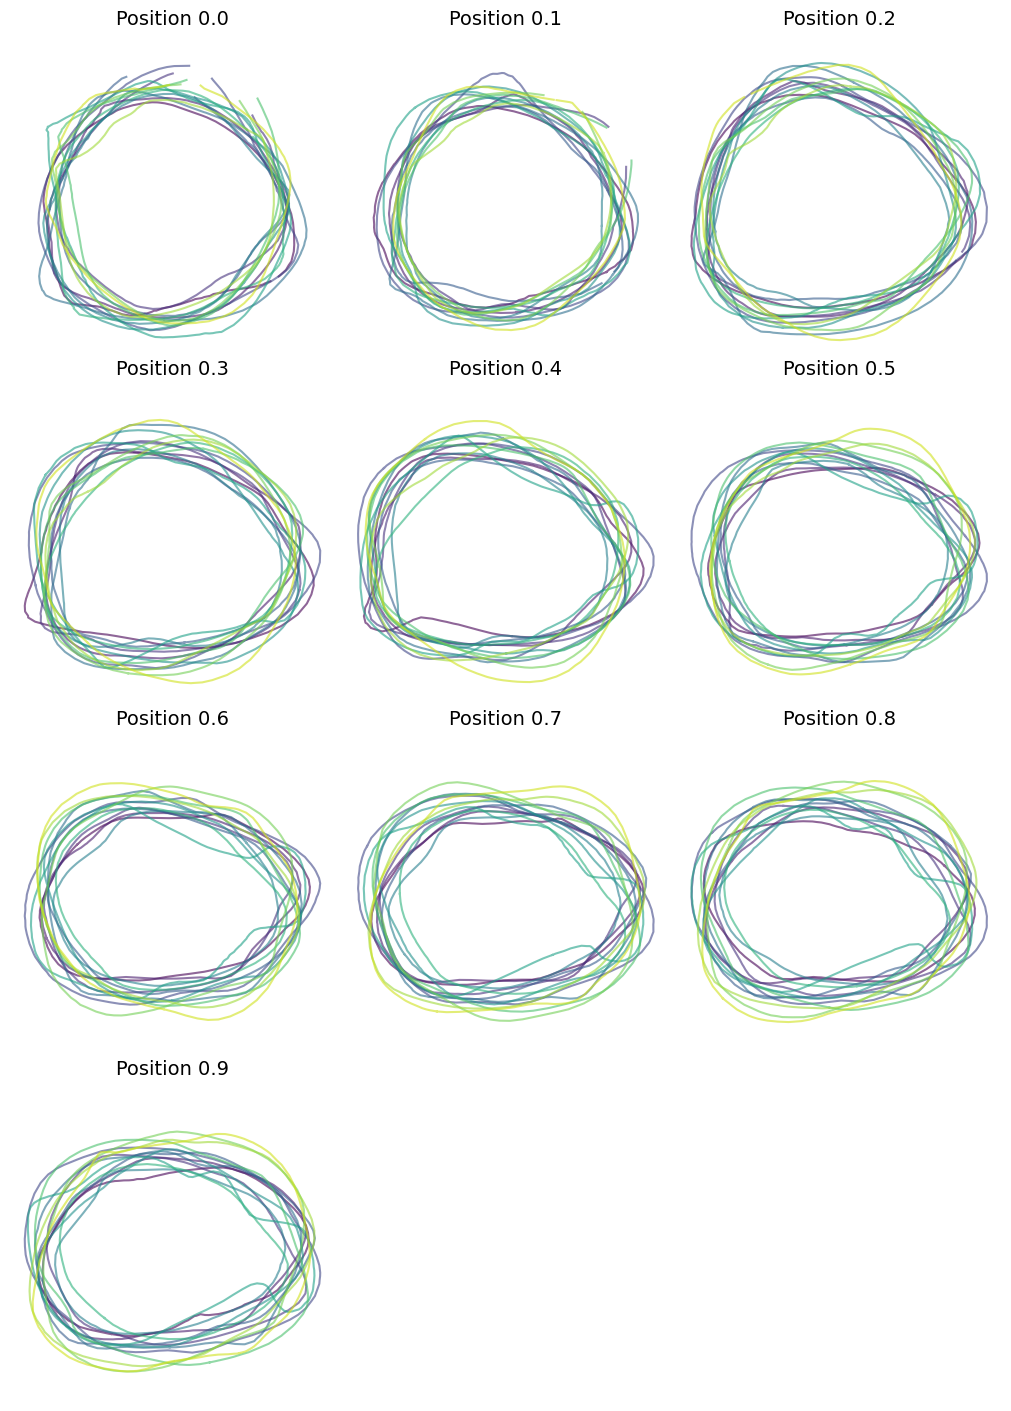

In [11]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

cmap = mpl.colormaps['viridis']

n_rows, n_cols = 4, 3
n_sections = 10
n_meshes = len(all_mesh_sections_left)

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(10, 14),
    constrained_layout=True
)

axes = axes.flatten()

for section_idx, ax in enumerate(axes):
    if section_idx >= n_sections:
        ax.axis("off")
        continue

    # collect this cross section from all meshes
    sections = [
        mesh_sections[section_idx]
        for mesh_sections in all_mesh_sections_left
    ]

    # PCA orientation fixed using first mesh
    pca = PCA(n_components=2)

    for mesh_idx, section in enumerate(sections):
        pca = PCA(n_components=2)
        section_2d = pca.fit_transform(section)
        ax.plot(
            section_2d[:, 0],
            section_2d[:, 1],
            alpha=0.6,
            color=cmap(mesh_idx / n_meshes)
        )

    ax.set_title(f"Position {section_idx/10}", pad=20)
    ax.axis("equal")
    ax.axis("off")


plt.savefig("../Figures/SI/cross_sections_left_selected_meshes.png", dpi=300)
plt.show()


SIFig5: Median values (red line) for the individual meshes (coloured lines) showing how the cross section aspect ratio varies along the length of the guard cell.

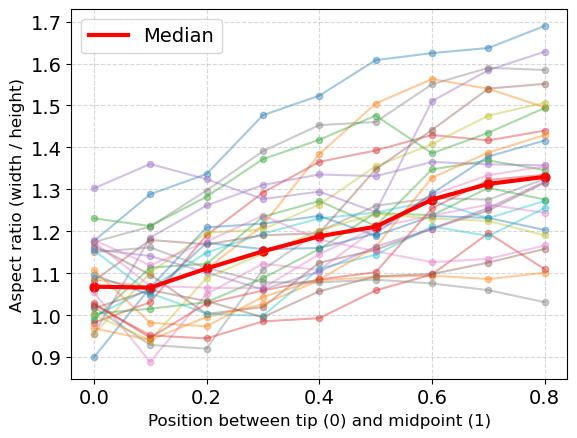

In [12]:
## For each set of cross sections, plot the position along the guard cell against the aspect ratio
import numpy as np
import matplotlib.pyplot as plt

positions = np.arange(0, 9)
x = positions / 10

all_curves = []  # store all aspect-ratio curves here

# Left meshes
for mesh in all_mesh_sections_left:
    ar_list = []
    for pos in positions:
        ar = csh.calculate_cross_section_aspect_ratios(mesh[pos])
        ar_list.append(ar)
    all_curves.append(ar_list)
    plt.plot(x, ar_list, alpha=0.4)
    plt.scatter(x, ar_list, s=20, alpha=0.4)

# Right meshes
for mesh in all_mesh_sections_right:
    ar_list = []
    for pos in positions:
        ar = csh.calculate_cross_section_aspect_ratios(mesh[pos])
        ar_list.append(ar)
    all_curves.append(ar_list)
    plt.plot(x, ar_list, alpha=0.4)
    plt.scatter(x, ar_list, s=20, alpha=0.4)

# Convert to array and take median across curves
all_curves = np.array(all_curves)
median_curve = np.median(all_curves, axis=0)

# Plot median in red
plt.plot(x, median_curve, color='red', linewidth=3, label='Median')
plt.scatter(x, median_curve, color='red', s=40)

plt.grid(linestyle='--', alpha=0.5)
plt.xlabel('Position between tip (0) and midpoint (1)')
plt.ylabel('Aspect ratio (width / height)')
plt.legend()
plt.savefig("../Figures/SI/aspect_ratio_vs_position_selected_meshes.png", dpi=300)
plt.show()


SIFig6: The greatest change to the midpoint guard cell shape occurs at low pressures (right). Little change is seen to the shape at the guard cell tips (left), suggesting that the greatest deformation occurs at a point maximising impact to the increase in pore area.

Processing mesh: Ac_DA_1_3_0.0
Processing mesh: Ac_DA_1_3_0.1
Processing mesh: Ac_DA_1_3_0.2
Processing mesh: Ac_DA_1_3_0.3
Processing mesh: Ac_DA_1_3_0.4
Processing mesh: Ac_DA_1_3_0.5
Processing mesh: Ac_DA_1_3_0.6
Processing mesh: Ac_DA_1_3_0.7
Processing mesh: Ac_DA_1_3_0.8
Processing mesh: Ac_DA_1_3_0.9
Processing mesh: Ac_DA_1_3_1.0
Processing mesh: Ac_DA_1_3_1.1
Processing mesh: Ac_DA_1_3_1.2
Processing mesh: Ac_DA_1_3_1.3
Processing mesh: Ac_DA_1_3_1.4
Processing mesh: Ac_DA_1_3_1.5
Processing mesh: Ac_DA_1_3_1.6
Processing mesh: Ac_DA_1_3_1.7
Processing mesh: Ac_DA_1_3_1.8
Processing mesh: Ac_DA_1_3_1.9


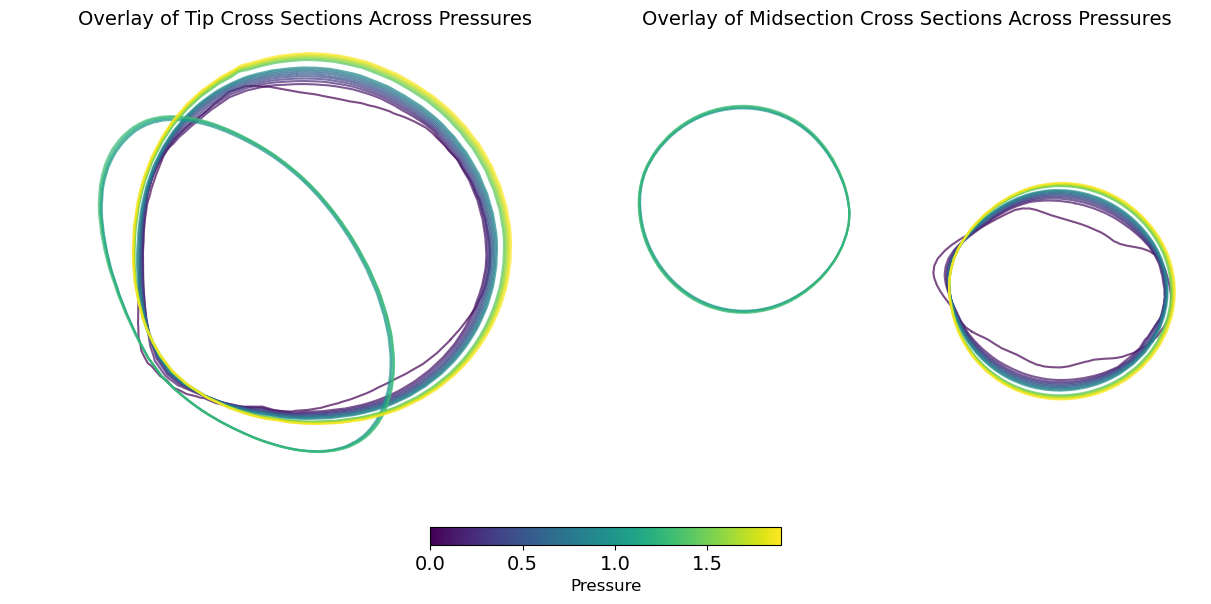

In [14]:
import matplotlib as mpl
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import numpy as np

import importlib
importlib.reload(importlib.import_module("cross_section_helpers"))
import numpy as np
import trimesh
import numpy as np
import cross_section_helpers as csh

obj_path = "../Meshes/Onion meshes/pressure_results/"
mesh_name = "Ac_DA_1_3_0.0"
mesh_id = "Ac_DA_1_3"

pressures = np.arange(0, 2.0, 0.1)

## Before we can use analyze_stomata_mesh, we need to get the midsection area at zero pressure
mesh0 = trimesh.load(obj_path + mesh_id + "_0.0.obj")
left_section, right_section = csh._extract_midsections(mesh0, dot_thresh=0.2)

mid_area_left_0 = csh.cross_section_area_2d(left_section)
mid_area_right_0 = csh.cross_section_area_2d(right_section)

all_meshes = []
all_mesh_sections_left = []
all_mesh_sections_right = []

for p in pressures:
    mesh_name = f"{mesh_id}_{p:.1f}"
    print("Processing mesh:", mesh_name)
    mesh = trimesh.load(obj_path + mesh_name + ".obj")
    wall_vertices = csh.find_wall_vertices_vertex_normals(mesh)
    csh.get_top_bottom_wall_centres(mesh, wall_vertices)

    section_points_right, section_points_left, section_traces_left, section_traces_right, [spline_x, spline_y, spline_z] = csh.analyze_stomata_mesh(obj_path + mesh_name+".obj", num_sections=20, n_points=40, visualize=False, mid_area_left_0 = mid_area_left_0, mid_area_right_0 = mid_area_right_0)

    all_meshes.append(mesh)
    all_mesh_sections_left.append(section_points_left)
    all_mesh_sections_right.append(section_points_right)

# Indices for tip and midsection
sections_to_plot = all_mesh_sections_right
tip_idx = 0
mid_idx = len(sections_to_plot[0]) // 2

section_names = ['Tip', 'Midsection']
section_indices = [tip_idx, mid_idx]

cmap = mpl.colormaps['viridis']

# Create a single figure with two subplots side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 6), constrained_layout=True)

for ax, section_name, section_idx in zip(axes, section_names, section_indices):
    # For this cross section index, collect the cross section from every mesh (i.e., every pressure)
    sections = [mesh_sections[section_idx] for mesh_sections in sections_to_plot]
    # Use PCA from the first pressure for consistent orientation
    pca = PCA(n_components=2).fit(sections[0])
    for t, section in enumerate(sections):
        section_2d = pca.transform(section)
        ax.plot(section_2d[:, 0], section_2d[:, 1], '-', color=cmap(t / (len(sections) - 1)), alpha=0.7)
    ax.set_title(f'Overlay of {section_name} Cross Sections Across Pressures')
    ax.axis('equal')
    ax.axis('off')

# Add a single colorbar for pressure, shared between both plots
sm = mpl.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=pressures[0], vmax=pressures[-1]))
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes, orientation='horizontal', fraction=0.04, pad=0.12)
cbar.set_label('Pressure')

plt.savefig('../Figures/SI/cross_section_overlays_1_3.png', dpi=300)
plt.show()


SIFig7: Initial increases in pressure result in an increase in guard cell height, with a corresponding decrease in guard cell width for models run with both a) experimental and b) idealised oval meshes.

In [15]:
## Takes about 6 minutes to run

from SI_plots import get_width_height
import os

mesh_dir_exp = Path("../Meshes/Onion meshes/pressure_results/")
mesh_paths_exp = [mesh_dir_exp / name for name in os.listdir(mesh_dir_exp) if name.endswith(".obj")]

mesh_dir_ideal = Path("../Meshes/Idealised/pressure_results/")
mesh_paths_ideal = [mesh_dir_ideal / name for name in os.listdir(mesh_dir_ideal) if name.endswith(".obj")]

## Only keep the oval meshes
mesh_paths_ideal = [path for path in mesh_paths_ideal if "oval" in path.stem]

df_midsections_exp = get_width_height(mesh_paths_exp, selected_meshes=selected_meshes)
df_midsections_ideal = get_width_height(mesh_paths_ideal, selected_meshes=selected_meshes)


,mesh_id,pressure,left_width,left_height,right_width,right_height,width_mean,height_mean
0,1_2,0.0,16.311106,10.086749,17.567968,10.643263,16.939537,10.365006
1,1_2,0.1,14.883586,12.113705,15.834589,12.618888,15.359087,12.366296
2,1_2,0.2,14.429426,12.564605,15.734825,12.887734,15.082125,12.726170
3,1_2,0.3,14.331670,12.826289,15.637421,13.185332,14.984545,13.005810
4,1_2,0.4,14.283505,13.028298,15.654058,13.410612,14.968781,13.219455
...,...,...,...,...,...,...,...,...
268,3_7,1.6,17.287522,17.519439,16.395980,16.185530,16.841751,16.852484
269,3_7,1.7,17.395866,17.599143,16.486946,16.266908,16.941406,16.933026
270,3_7,1.8,17.500821,17.679687,16.586341,16.343603,17.043581,17.011645
271,3_7,1.9,17.598272,17.763317,16.678044,16.425930,17.138158,17.094624


,mesh_id,pressure,left_width,left_height,right_width,right_height,width_mean,height_mean
0,1_2,0.0,16.599395,10.877638,16.599296,10.877573,16.599346,10.877606
1,1_2,0.1,15.491708,12.515685,15.531814,12.515694,15.511761,12.515689
2,1_2,0.2,15.469942,12.860688,15.478512,12.860563,15.474227,12.860626
3,1_2,0.3,15.425759,13.110939,15.445253,13.109254,15.435506,13.110096
4,1_2,0.4,15.425075,13.307456,15.424706,13.308621,15.424890,13.308038
...,...,...,...,...,...,...,...,...
248,3_6,1.7,16.931180,17.063073,16.932369,17.063331,16.931775,17.063202
249,3_6,1.8,17.016495,17.166863,17.016738,17.167083,17.016617,17.166973
250,3_6,1.9,17.101692,17.268792,17.101816,17.267917,17.101754,17.268355
251,3_6,2.0,17.186927,17.367646,17.186841,17.369091,17.186884,17.368368


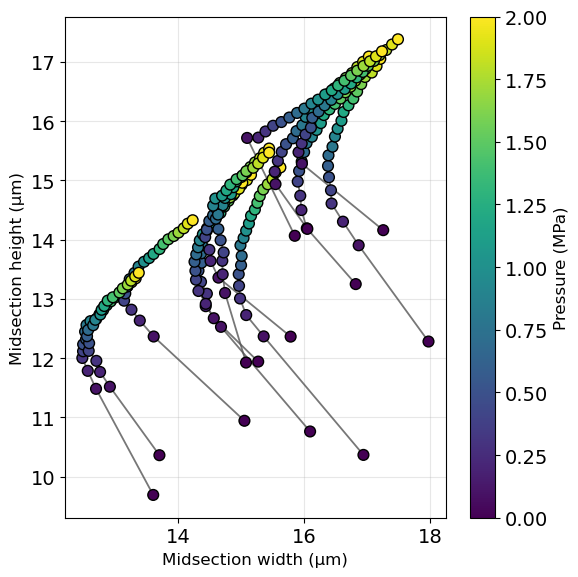

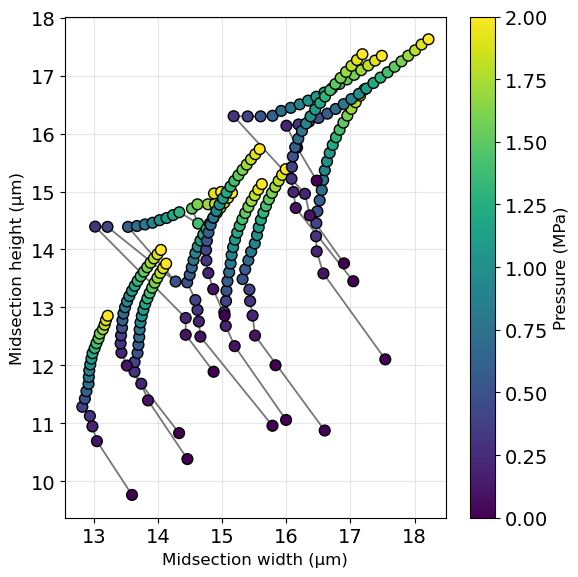

In [17]:
from SI_plots import plot_SI7

plot_SI7(df_midsections_exp, filename="../Figures/SI/midsection_height_width_oval_exp.png")
plot_SI7(df_midsections_ideal, filename="../Figures/SI/midsection_height_width_oval_ideal.png")

/tmp/ipykernel_151120/242128376.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mesh_to_plot.sort_values("Pressure", inplace=True)


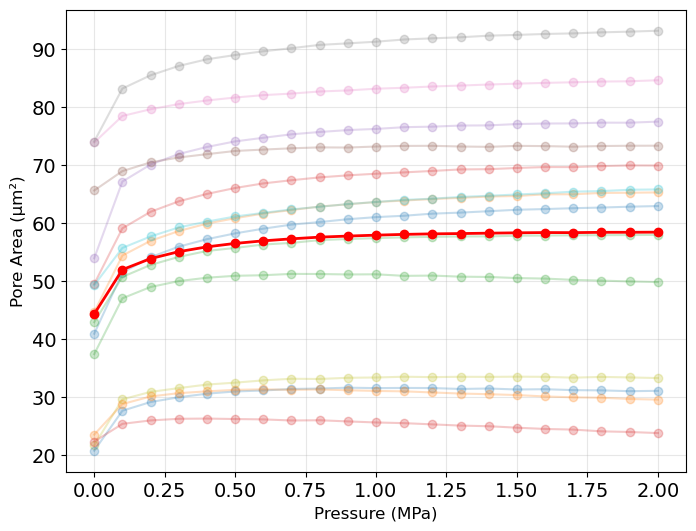

In [25]:
## Plot with all of the meshes pressure - pore area values. Or maybe the mean?

fig, ax = plt.subplots(figsize=(8, 6))

all_selected = confocal_df[confocal_df["Mesh ID"].isin(selected_meshes)]

for mesh_id in selected_meshes:
    mesh_to_plot = all_selected[all_selected["Mesh ID"] == mesh_id]
    mesh_to_plot.sort_values("Pressure", inplace=True)
    ax.plot(
        mesh_to_plot["Pressure"].values,
        mesh_to_plot["Pore Area"].values,
        'o-',
        label=mesh_id,
        alpha=0.25,
    )

mean_df = (
    all_selected.groupby("Pressure", as_index=False)["Pore Area"]
    .mean()
    .sort_values("Pressure")
)
ax.plot(
    mean_df["Pressure"].values,
    mean_df["Pore Area"].values,
    'o-',
    color='red',
    alpha=1.0,
    linewidth=2,
    markersize=6,
    label='Mean',
)

ax.grid(alpha=0.3)
ax.set_xlabel("Pressure (MPa)")
ax.set_ylabel("Pore Area (µm²)")

plt.savefig("../Figures/SI/pore_area_vs_pressure_selected_meshes.png", dpi=300)
plt.show()